In [1]:
from scipy import stats
from statsmodels.stats.weightstats import ztest
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep
import numpy as np
import statistics as st
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score, precision_score, average_precision_score

data = pd.read_csv('nba_second_round_history_augmented.csv')
data

,Season,Team,Opponent,Games played,Average Points scored,Average Points allowed,Offensive Rating,Defensive Rating,eFG%,Opp eFG%,TOV%,Opp TOV%,ORB%,Opp ORB%,FT/FGA,Opp FT/FGA,Champion,Actual Wins (%),Team TS%,Opp TS%
0,1984,BOS,NYK,7,111.0,103.0,113.9,105.7,49.8,48.4,14.2,16.0,38.7,35.0,28.5,29.6,True,57.143,54.9350,53.9574
1,1984,MIL,NJN,6,98.2,96.3,102.8,100.9,47.1,40.5,18.3,12.2,32.6,35.5,37.3,34.0,False,66.667,54.0129,47.1452
2,1984,LAL,DAL,5,120.6,106.2,121.9,107.4,57.0,45.4,12.8,11.9,37.8,35.1,20.0,23.2,False,80.000,59.7550,50.4063
3,1984,PHO,UTA,6,103.7,101.0,107.0,104.3,46.2,46.8,12.9,15.3,33.9,32.4,23.0,30.0,False,66.667,51.2187,52.6627
4,1985,BOS,DET,6,120.5,112.7,118.1,110.4,51.9,47.8,13.6,11.4,37.1,35.7,30.2,19.6,False,66.667,57.8882,51.6914
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
167,2025,MIN,GSW,5,109.0,101.8,113.9,106.4,56.7,49.4,16.8,15.4,26.2,32.0,18.9,22.7,False,80.000,59.8165,53.7419
168,2026,NYK,PHI,4,124.3,102.0,132.3,108.6,63.6,51.4,12.6,13.7,32.1,21.6,23.3,25.5,True,100.000,66.2102,55.9456
169,2026,CLE,DET,7,108.9,107.4,115.6,114.1,53.7,52.5,14.6,14.0,29.4,32.3,29.9,20.3,False,57.143,58.5721,56.1966
170,2026,SAS,MIN,6,120.7,104.5,119.0,103.1,56.5,46.4,12.5,12.0,26.9,24.0,25.0,19.1,False,66.667,60.5756,50.2211


"Series Score" of the advancing teams is the data viewers can most easily access through medias, compared to avarage point difffence, Net Ratings, Efficient Field Goal%, etc.
We would like to test if teams advancing with different series score have different championship proportion. Data was collected from 1984 to 2025 of the NBA playoffs second round.

In [2]:
dominant = data[data['Games played'] <= 5]
non_dominant = data[data['Games played'] > 5]

In [4]:
# check if two sample proportion z-test is appropriate
n1p1 = len(dominant[dominant['Champion'] == True])
n1q1 = len(dominant) - n1p1
n2p2 = len(non_dominant[non_dominant['Champion'] == True])
n2q2 = len(non_dominant) - n2p2
if n1p1 >= 15 and n1q1 >= 15 and n2p2 >= 15 and n2q2 >= 15:
    print("Two-sample proportion z-test is appropriate.")
if n1p1 < 15:
    print(f"Two-sample proportion z-test is not appropriate. Number of dominant champions is less than 15 ({n1p1}).")
if n1q1 < 15:
    print(f"Two-sample proportion z-test is not appropriate. Number of dominant non-champions is less than 15 ({n1q1}).")
if n2p2 < 15:
    print(f"Two-sample proportion z-test is not appropriate. Number of non-dominant champions is less than 15 ({n2p2}).")
if n2q2 < 15:
    print(f"Two-sample proportion z-test is not appropriate. Number of non-dominant non-champions is less than 15 ({n2q2}).")

Two-sample proportion z-test is appropriate.


H0: p1 = p2 ;
H1: p1 > p2

In [5]:
test_stat, p_value = proportions_ztest([n1p1, n2p2], [len(dominant), len(non_dominant)], alternative='larger')
print(f"Z-test statistic: {test_stat:.4f}")
print(f"P-value: {p_value:.4f}")
if p_value < 0.05:
    print("Reject the null hypothesis: The championship rates in dominant teams are larger than non-dominant teams.")
else:
    print("Fail to reject the null hypothesis: There is no significant difference in championship rates between dominant and non-dominant teams.")

CI_low, _ = confint_proportions_2indep(
    count1=n1p1,
    nobs1=len(dominant),
    count2=n2p2,
    nobs2=len(non_dominant),
    method='wald',
    alpha=0.10
)    
print(f'Confindence Interval: ({CI_low:.4f}, 1.0000)')

SE = math.sqrt(n1p1*n1q1/len(dominant)**3 + n2p2*n2q2/len(non_dominant)**3)
CI_low = n1p1/len(dominant) - n2p2/len(non_dominant) - stats.norm.ppf(0.95) * SE
# CI_high = n1p1/len(dominant) - n2p2/len(non_dominant) + stats.norm.ppf(0.95) * SE
print(f'Confident Interval (hand calculated): ({CI_low:.4f}, 1.0000)')

Z-test statistic: 2.1275
P-value: 0.0167
Reject the null hypothesis: The championship rates in dominant teams are larger than non-dominant teams.
Confindence Interval: (0.0312, 1.0000)
Confident Interval (hand calculated): (0.0312, 1.0000)


We are curious about which statistic best predicts the championship, so after standardising the data (to neutralise the influence of era), we perform **Random Forest**

In [28]:
standard = pd.read_csv('nba_second_round_history_standardised.csv')
# standard = standard[standard['Season'] < 2026]
# Chronological split to prevent time travalling
train_data = standard[standard['Season'] < 2015]
test_data = standard[standard['Season'] >= 2015]

features = [
    'Offensive Rating',
    'Defensive Rating',
    'eFG% Difference',
    'TOV% Difference',       
    'ORB% Difference',       
    'FT/FGA Difference',     
    'Games played'           
]

print("Features used for training:", features)  

x_train = train_data[features]
y_train = train_data['Champion']

x_test = test_data[features]
y_test = test_data['Champion']

model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model.fit(x_train, y_train)

print(f"\n--- Threshold Optimization ---")
y_probs = model.predict_proba(x_test)[:, 1]

threshold = 0.35
y_pred_adj = (y_probs >= threshold).astype(int)

print(f"Confusion Matrix:\n {confusion_matrix(y_test, y_pred_adj)}")
print("Classification Report:")
print(classification_report(y_test, y_pred_adj, target_names=['Non-Champion', 'Champion']))
print('Recall:' + str(recall_score(y_test, y_pred_adj)))
print('Precision:' + str(precision_score(y_test, y_pred_adj, zero_division=0)))
print('F1-Score:' + str(f1_score(y_test, y_pred_adj)))

rf_pr_auc = average_precision_score(y_test, y_probs)
print('PR-AUC Score:' + str(rf_pr_auc))

print('\n\n ====== Feature importance (RF) ======== \n ')
importances = model.feature_importances_

# Create a clean, sorted table of what matters most
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(importance_df)

Features used for training: ['Offensive Rating', 'Defensive Rating', 'eFG% Difference', 'TOV% Difference', 'ORB% Difference', 'FT/FGA Difference', 'Games played']

--- Threshold Optimization ---
Confusion Matrix:
 [[22 14]
 [ 4  8]]
Classification Report:
              precision    recall  f1-score   support

Non-Champion       0.85      0.61      0.71        36
    Champion       0.36      0.67      0.47        12

    accuracy                           0.62        48
   macro avg       0.60      0.64      0.59        48
weighted avg       0.73      0.62      0.65        48

Recall:0.6666666666666666
Precision:0.36363636363636365
F1-Score:0.47058823529411764
PR-AUC Score:0.4126363839653353


 ====== Feature importance (RF) ======== 
 
             Feature  Importance
0   Offensive Rating    0.184735
1   Defensive Rating    0.183978
2    eFG% Difference    0.172353
3    TOV% Difference    0.160448
4    ORB% Difference    0.138158
5  FT/FGA Difference    0.110424
6       Games played   

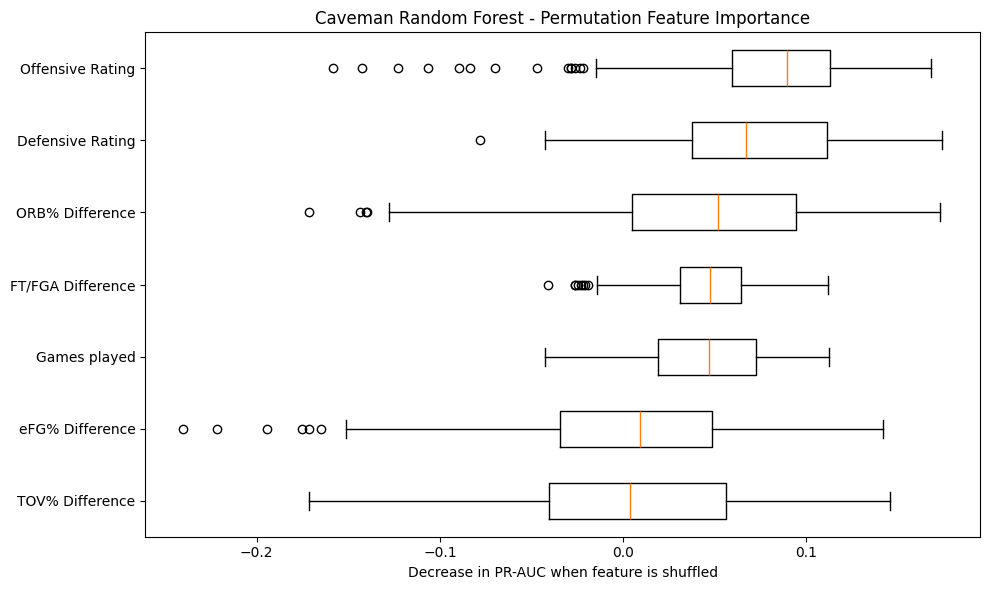

             Feature  Importance_Mean  Importance_Std
6   Offensive Rating         0.081538        0.050977
5   Defensive Rating         0.070506        0.047665
4    ORB% Difference         0.045721        0.062688
3  FT/FGA Difference         0.044817        0.027167
2       Games played         0.044797        0.033863
1    eFG% Difference         0.004870        0.067506
0    TOV% Difference         0.004020        0.065442


In [29]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# Calculate Permutation Importance on your caveman model
result = permutation_importance(
    model, x_test, y_test, 
    n_repeats=300, 
    random_state=42,
    scoring='average_precision' 
)

# Sort and plot
sorted_idx = result.importances_mean.argsort()

fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(result.importances[sorted_idx].T,
           vert=False, tick_labels=x_test.columns[sorted_idx])
ax.set_title("Caveman Random Forest - Permutation Feature Importance")
ax.set_xlabel("Decrease in PR-AUC when feature is shuffled")
plt.tight_layout()
plt.show()

# Also print the raw numbers for clarity
importance_df = pd.DataFrame({
    'Feature': x_test.columns[sorted_idx],
    'Importance_Mean': result.importances_mean[sorted_idx],
    'Importance_Std': result.importances_std[sorted_idx]
}).sort_values('Importance_Mean', ascending=False)

print(importance_df)

The model heavily relied on Offensive Rating, Defensive Rating, and eFG% Difference to build its internal logic. When we tested the model on unseen data, Offensive and Defensive Rating remained the most critical features, proving their generalizability. However, the importance of eFG% Difference became unstable (high standard deviation), suggesting it might be noisier in the playoffs than the raw efficiency ratings."

Inhanced RF

In [ ]:
# 1. Define the universal basketball rules (1 = Higher is better for winning, -1 = Higher is worse)
rule_book = {
    'Offensive Rating': 1,     # Better offense = More wins
    'Defensive Rating': -1,    # Higher DRtg = Gave up more points = Less wins
    'TOV%': -1,          
    'Opp TOV%': 1,       
    'ORB%': 1,           
    'DRB%': 1,           
    'FT/FGA': 1,         
    'Opp FT/FGA': -1,    
    'Games played': 0    
}

# 2. Dynamically build the constraint array based on your exact feature list
mono_constraints = [rule_book.get(feature, 0) for feature in features]

# 3. The Ultimate NBA Random Forest
model = RandomForestClassifier(

    n_estimators=100, 

    class_weight='balanced_subsample',

    max_depth=4,

    min_samples_leaf=4,

    min_impurity_decrease=0.005,  # Ignore splits that don't improve purity by at least 0.5%

    monotonic_cst=mono_constraints, # Apply domain knowledge of basketball

    random_state=42

)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print("Classification Report:")

print(classification_report(y_test, y_pred, target_names=['Non-Champion', 'Champion']))



print("Confusion Matrix:")

print(confusion_matrix(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

Non-Champion       0.81      0.79      0.80        33
    Champion       0.42      0.45      0.43        11

    accuracy                           0.70        44
   macro avg       0.61      0.62      0.62        44
weighted avg       0.71      0.70      0.71        44

Confusion Matrix:
[[26  7]
 [ 6  5]]


In [ ]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

# 1. Monotonic Constraints (Keep the domain knowledge!)
rule_book = {
    'Offensive Rating': 1,     # Better offense = More wins
    'Defensive Rating': -1,    # Higher DRtg = Gave up more points = Less wins
    'TOV%': -1,          
    'Opp TOV%': 1,       
    'ORB%': 1,           
    'DRB%': 1,           
    'FT/FGA': 1,         
    'Opp FT/FGA': -1,    
    'Games played': 0    
}
mono_constraints = [rule_book.get(feature, 0) for feature in features]

# 2. Setup Time-Series Cross Validation (No time traveling!)
# We use 5 splits, maintaining chronological order
tscv = TimeSeriesSplit(n_splits=5)

# 3. Define the Base Model (Relaxed constraints)
base_rf = RandomForestClassifier(
    n_estimators=100, 
    class_weight='balanced_subsample',
    monotonic_cst=mono_constraints, # Keep the basketball logic!
    random_state=42
)

# 4. Setup the Grid Search for ccp_alpha
# We test a range of pruning values. 0.0 means no pruning.
param_grid = {
    'ccp_alpha': [0.0, 0.001, 0.005, 0.01, 0.02, 0.03],
    'max_depth': [3, 4, 5, None] # Let CV decide if depth limits help
}

# Setup GridSearch
# We optimize for 'f1' because accuracy is misleading on imbalanced data
grid_search = GridSearchCV(
    estimator=base_rf,
    param_grid=param_grid,
    cv=tscv,
    scoring='f1', 
    n_jobs=-1
)

# 5. Fit and find the sweet spot
print("Tuning hyperparameters...")
grid_search.fit(x_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best F1 Score on CV: {grid_search.best_score_:.3f}")

# 6. Evaluate the best model on the Test Set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(x_test)

print("\n--- Tuned Random Forest Report ---")
print(classification_report(y_test, y_pred, target_names=['Non-Champion', 'Champion']))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Tuning hyperparameters...
Best Parameters: {'ccp_alpha': 0.0, 'max_depth': 3}
Best F1 Score on CV: 0.348

--- Tuned Random Forest Report ---
              precision    recall  f1-score   support

Non-Champion       0.82      0.82      0.82        33
    Champion       0.45      0.45      0.45        11

    accuracy                           0.73        44
   macro avg       0.64      0.64      0.64        44
weighted avg       0.73      0.73      0.73        44

Confusion Matrix:
[[27  6]
 [ 6  5]]


In [5]:
record = pd.DataFrame(columns=['Decay', 'Threshold', 'Precision', 'Recall', 'F1-Score'])

for decay in range(10, 100+1):
    # --- CHANGE 1: Time-Decay Weighting ---
    # Exponentially weight recent seasons in the training set
    max_season = train_data['Season'].max()
    time_weights = np.exp(-decay * 0.001 * (max_season - train_data['Season']))

    # --- CHANGE 2: The Unshackled RF ---
    # Remove monotonic_cst, let it breathe. Keep class_weight to handle the 3:1 imbalance.
    model = RandomForestClassifier(
        n_estimators=1000,         # More trees for stability
        # class_weight='balanced_subsample',
        max_depth=None,            # Let it grow to find complex interactions
        min_samples_leaf=3,        # Keep this just to prevent 1-team leaves
        max_features='sqrt',       # Standard RF randomness
        random_state=42
    )

    # Fit with TIME WEIGHTS
    model.fit(x_train, y_train, sample_weight=time_weights)

    # --- CHANGE 3: Threshold Moving ---
    print(f"\n--- Threshold Optimization ---")
    y_probs = model.predict_proba(x_test)[:, 1]

    for threshold in [0.30, 0.325, 0.35, 0.375]:
        y_pred_adj = (y_probs >= threshold).astype(int)
        recall = recall_score(y_test, y_pred_adj)
        precision = precision_score(y_test, y_pred_adj, zero_division=0)
        f1 = f1_score(y_test, y_pred_adj)
        print(f"Threshold: {threshold:.2f}")
        print(f"Confusion Matrix:\n {confusion_matrix(y_test, y_pred_adj)}")
        record.loc[len(record)] = {
            'Decay': decay,
            'Threshold': threshold,
            'Precision': precision,
            'Recall': recall,
            'F1-Score': f1
        }


--- Threshold Optimization ---
Threshold: 0.30
Confusion Matrix:
 [[24  9]
 [ 7  4]]
Threshold: 0.33
Confusion Matrix:
 [[25  8]
 [ 7  4]]
Threshold: 0.35
Confusion Matrix:
 [[28  5]
 [ 7  4]]
Threshold: 0.38
Confusion Matrix:
 [[31  2]
 [ 9  2]]

--- Threshold Optimization ---
Threshold: 0.30
Confusion Matrix:
 [[22 11]
 [ 7  4]]
Threshold: 0.33
Confusion Matrix:
 [[25  8]
 [ 7  4]]
Threshold: 0.35
Confusion Matrix:
 [[26  7]
 [ 7  4]]
Threshold: 0.38
Confusion Matrix:
 [[30  3]
 [ 8  3]]

--- Threshold Optimization ---
Threshold: 0.30
Confusion Matrix:
 [[22 11]
 [ 6  5]]
Threshold: 0.33
Confusion Matrix:
 [[25  8]
 [ 7  4]]
Threshold: 0.35
Confusion Matrix:
 [[27  6]
 [ 7  4]]
Threshold: 0.38
Confusion Matrix:
 [[31  2]
 [ 9  2]]

--- Threshold Optimization ---
Threshold: 0.30
Confusion Matrix:
 [[20 13]
 [ 6  5]]
Threshold: 0.33
Confusion Matrix:
 [[25  8]
 [ 7  4]]
Threshold: 0.35
Confusion Matrix:
 [[27  6]
 [ 8  3]]
Threshold: 0.38
Confusion Matrix:
 [[29  4]
 [ 8  3]]

--- Thr

In [6]:
record.sort_values(by='F1-Score', ascending=False, inplace=True)
record['Decay'] = record['Decay'] * 0.001
record

,Decay,Threshold,Precision,Recall,F1-Score
52,0.023,0.300,0.428571,0.545455,0.480000
28,0.017,0.300,0.400000,0.545455,0.461538
80,0.030,0.300,0.375000,0.545455,0.444444
84,0.031,0.300,0.375000,0.545455,0.444444
104,0.036,0.300,0.375000,0.545455,0.444444
...,...,...,...,...,...
289,0.082,0.325,0.200000,0.181818,0.190476
326,0.091,0.350,0.200000,0.181818,0.190476
285,0.081,0.325,0.200000,0.181818,0.190476
197,0.059,0.325,0.181818,0.181818,0.181818


In [24]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import average_precision_score

# --- Assuming x_train, y_train, x_test, y_test, and final_custom_weights are ready ---

# We need a separate time-decay array for CV because CV splits the data further
champ_multiplier = (y_train == 0).sum() / (y_train == 1).sum()
base_weights = np.where(y_train == 1, champ_multiplier, 1.0)
max_season = train_data['Season'].max()
time_decay = np.exp(-0.1 * (max_season - train_data['Season']))
final_custom_weights = base_weights * time_decay

# Time-Series Cross Validation (NO DATA LEAKAGE!)
tscv = TimeSeriesSplit(n_splits=3)

# ==========================================
# 1. RANDOM FOREST GRID SEARCH
# ==========================================
print("--- Tuning Random Forest ---")

rule_book = {
    'Offensive Rating': 1,     # Better offense = More wins
    'Defensive Rating': -1,    # Higher DRtg = Gave up more points = Less wins
    'TOV%': -1,          
    'Opp TOV%': 1,       
    'ORB%': 1,           
    'DRB%': 1,           
    'FT/FGA': 1,         
    'Opp FT/FGA': -1,    
    'Games played': 0    
}
mono_constraints = [rule_book.get(feature, 0) for feature in features]

rf_params = {
    'n_estimators': [500, 1000, 1500],
    'max_depth': [3, 4, 5],
    'min_samples_leaf': [3, 4, 5],
    'ccp_alpha': [0.0, 0.005, 0.01],
    'monotonic_cst': [None, mono_constraints]
}

rf = RandomForestClassifier(random_state=42)

rf_grid = GridSearchCV(
    rf, rf_params, 
    cv=tscv, 
    scoring='average_precision', # Optimize for PR-AUC!
    n_jobs=-1
)

# Pass the time weights into the fit
rf_grid.fit(x_train, y_train, sample_weight=final_custom_weights)

best_rf = rf_grid.best_estimator_
rf_probs = best_rf.predict_proba(x_test)[:, 1]
rf_pr_auc = average_precision_score(y_test, rf_probs)

print(f"Best RF Params: {rf_grid.best_params_}")
print(f"Optimized RF PR-AUC: {rf_pr_auc:.3f}\n")


# ==========================================
# 2. LIGHTGBM GRID SEARCH (Heavy Regularization)
# ==========================================
print("--- Tuning LightGBM ---")
lgbm_params = {
    'n_estimators': [25, 50, 75],
    'learning_rate': [0.02 ,0.035, 0.05],      # Slow learning
    'max_depth': [2, 3],                # Very shallow trees!
    'min_child_samples': [3, 5],       # Force larger leaves to prevent memorizing 1 team
    'subsample': [0.3, 0.4, 0.5],            # Row sampling
    'colsample_bytree': [0.2, 0.3, 0.4, 0.5],     # Column sampling
    'reg_alpha': [0.3, 0.5, 0.7],            # L1 regularization
    'reg_lambda': [0.8, 0.9, 1.0]            # L2 regularization
}

# Handle class imbalance internally for LGBM
champ_multiplier = (y_train == 0).sum() / (y_train == 1).sum()
lgbm = LGBMClassifier(scale_pos_weight=champ_multiplier, random_state=42, verbose=-1)

lgbm_grid = GridSearchCV(
    lgbm, lgbm_params, 
    cv=tscv, 
    scoring='average_precision',
    n_jobs=-1
)

# Pass time weights
lgbm_grid.fit(x_train, y_train, sample_weight=time_decay)

best_lgbm = lgbm_grid.best_estimator_
lgbm_probs = best_lgbm.predict_proba(x_test)[:, 1]
lgbm_pr_auc = average_precision_score(y_test, lgbm_probs)

print(f"Best LGBM Params: {lgbm_grid.best_params_}")
print(f"Optimized LGBM PR-AUC: {lgbm_pr_auc:.3f}\n")


# ==========================================
# 3. FINAL VERDICT
# ==========================================
# print(f"Baseline (Random Guess): 0.250")
# if rf_pr_auc > lgbm_pr_auc:
#     print("\n✅ Random Forest remains the superior model for this data.")
# else:
#     print("\n✅ LightGBM overcame its overfitting and pulled ahead!")

--- Tuning Random Forest ---
Best RF Params: {'ccp_alpha': 0.005, 'max_depth': 3, 'min_samples_leaf': 5, 'monotonic_cst': None, 'n_estimators': 1500}
Optimized RF PR-AUC: 0.252

--- Tuning LightGBM ---
Best LGBM Params: {'colsample_bytree': 0.4, 'learning_rate': 0.02, 'max_depth': 3, 'min_child_samples': 3, 'n_estimators': 25, 'reg_alpha': 0.7, 'reg_lambda': 0.9, 'subsample': 0.3}
Optimized LGBM PR-AUC: 0.244



In [29]:
from sklearn.metrics import average_precision_score
from sklearn.inspection import permutation_importance
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt

# Best LGBM Params: {'subsample': 0.6, 'reg_lambda': 2.0, 'reg_alpha': 0.1, 'n_estimators': 200, 'min_child_samples': 5, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
# Optimized LGBM PR-AUC: 0.243

# LightGBM couldn't beat Random Forest. Stick with the RF 0.332 model.

# Manually calculate unified weights for both models
champ_multiplier = (y_train == 0).sum() / (y_train == 1).sum()
base_weights = np.where(y_train == 1, champ_multiplier, 1.0)
max_season = train_data['Season'].max()
time_decay = np.exp(-0.1 * (max_season - train_data['Season']))
final_custom_weights = base_weights * time_decay

# ==========================================
# MODEL 1: THE SAFE RANDOM FOREST
# ==========================================
rf = RandomForestClassifier(
    n_estimators=500, 
    max_depth=4,                 
    min_samples_leaf=4,          
    random_state=42
)
rf.fit(x_train, y_train, sample_weight=final_custom_weights)
rf_probs = rf.predict_proba(x_test)[:, 1]
rf_pr_auc = average_precision_score(y_test, rf_probs)

# ==========================================
# MODEL 2: THE AGGRESSIVE LIGHTGBM
# ==========================================
lgbm = LGBMClassifier(
    n_estimators=50,
    learning_rate=0.02,        # Slow learning
    max_depth=3,               # Very shallow trees
    min_child_samples=3,
    subsample=0.3,             # Prevent memorizing specific teams
    colsample_bytree=0.4,      # Only look at 70% of features per tree
    scale_pos_weight=champ_multiplier, # Handle class imbalance
    reg_alpha=0.7,
    reg_lambda=0.9,
    random_state=42,
    verbose=-1                 # Suppress training logs
)
lgbm.fit(x_train, y_train, sample_weight=time_decay) # LGBM handles class weight internally, just pass time decay
lgbm_probs = lgbm.predict_proba(x_test)[:, 1]
lgbm_pr_auc = average_precision_score(y_test, lgbm_probs)

# ==========================================
# THE VERDICT
# ==========================================
print(f"Random Forest PR-AUC: {rf_pr_auc:.3f}")
print(f"LightGBM PR-AUC:      {lgbm_pr_auc:.3f}")
print(f"Baseline (Random):    0.250\n")

# Pick the winner
if lgbm_pr_auc > rf_pr_auc and lgbm_pr_auc > 0.30:
    print("✅ LightGBM Wins! Generating Permutation Importance...")
    best_model = lgbm
    best_probs = lgbm_probs
elif rf_pr_auc > lgbm_pr_auc and rf_pr_auc > 0.30:
    print("✅ Random Forest Wins! Generating Permutation Importance...")
    best_model = rf
    best_probs = rf_probs
else:
    print("⚠️ Neither model broke the 0.30 barrier. The signal is too weak.")

# Generate Importance for the winner
if 'best_model' in locals():
    result = permutation_importance(
        best_model, x_test, y_test, 
        n_repeats=30, 
        random_state=42,
        scoring='average_precision' 
    )
    
    sorted_idx = result.importances_mean.argsort()
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.boxplot(result.importances[sorted_idx].T,
               vert=False, labels=x_test.columns[sorted_idx])
    ax.set_title(f"Permutation Importance ({type(best_model).__name__})")
    ax.set_xlabel("Decrease in PR-AUC when feature is shuffled")
    plt.tight_layout()
    plt.show()

Random Forest PR-AUC: 0.255
LightGBM PR-AUC:      0.240
Baseline (Random):    0.250

⚠️ Neither model broke the 0.30 barrier. The signal is too weak.


In [ ]:
print('\n\n ====== Feature importance (RF) ======== \n ')
importances = model.feature_importances_

# Create a clean, sorted table of what matters most
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(importance_df)